In [2]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt

# 1. Download Stock Data
ticker = "AAPL"
df = yf.download(ticker, start="2020-01-01", end="2024-01-01")

# FIX: If yfinance returns MultiIndex columns, flatten them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Ensure data is clean
df = df.dropna()
print(f"Data for {ticker} cleaned and loaded!")
df.head()

[*********************100%***********************]  1 of 1 completed

Data for AAPL cleaned and loaded!


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


In [3]:
# 1. Simple Moving Averages (SMA)
df['SMA_20'] = ta.sma(df['Close'], length=20)
df['SMA_50'] = ta.sma(df['Close'], length=50)

# 2. Relative Strength Index (RSI)
df['RSI_14'] = ta.rsi(df['Close'], length=14)

# 3. Moving Average Convergence Divergence (MACD)
# We calculate it as a separate dataframe
macd_df = ta.macd(df['Close'], fast=12, slow=26, signal=9)

# Join only if macd_df is not None
if macd_df is not None:
    df = pd.concat([df, macd_df], axis=1)
    print("Indicators Calculated Successfully!")
else:
    print("Error: MACD calculation failed. Ensure you have enough data points.")

display(df.tail())

Indicators Calculated Successfully!


,Close,High,Low,Open,Volume,SMA_20,SMA_50,RSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9
Date,,,,,,,,,,,
2023-12-22,191.609497,193.400885,190.985970,193.173239,37149600,191.677264,183.401252,54.672863,2.630683,-0.601550,3.232233
2023-12-26,191.065094,191.896454,190.847355,191.619334,28919300,191.838588,183.686989,53.089935,2.302597,-0.743709,3.046306
2023-12-27,191.164093,191.510500,189.125276,190.510890,48087700,191.974674,183.977277,53.354416,2.027206,-0.815280,2.842486
2023-12-28,191.589661,192.658558,191.183873,192.143900,34049900,192.183009,184.307111,54.540928,1.822291,-0.816156,2.638447
2023-12-29,190.550476,192.401245,189.758698,191.906385,42672100,192.310683,184.642059,51.121350,1.558079,-0.864294,2.422373


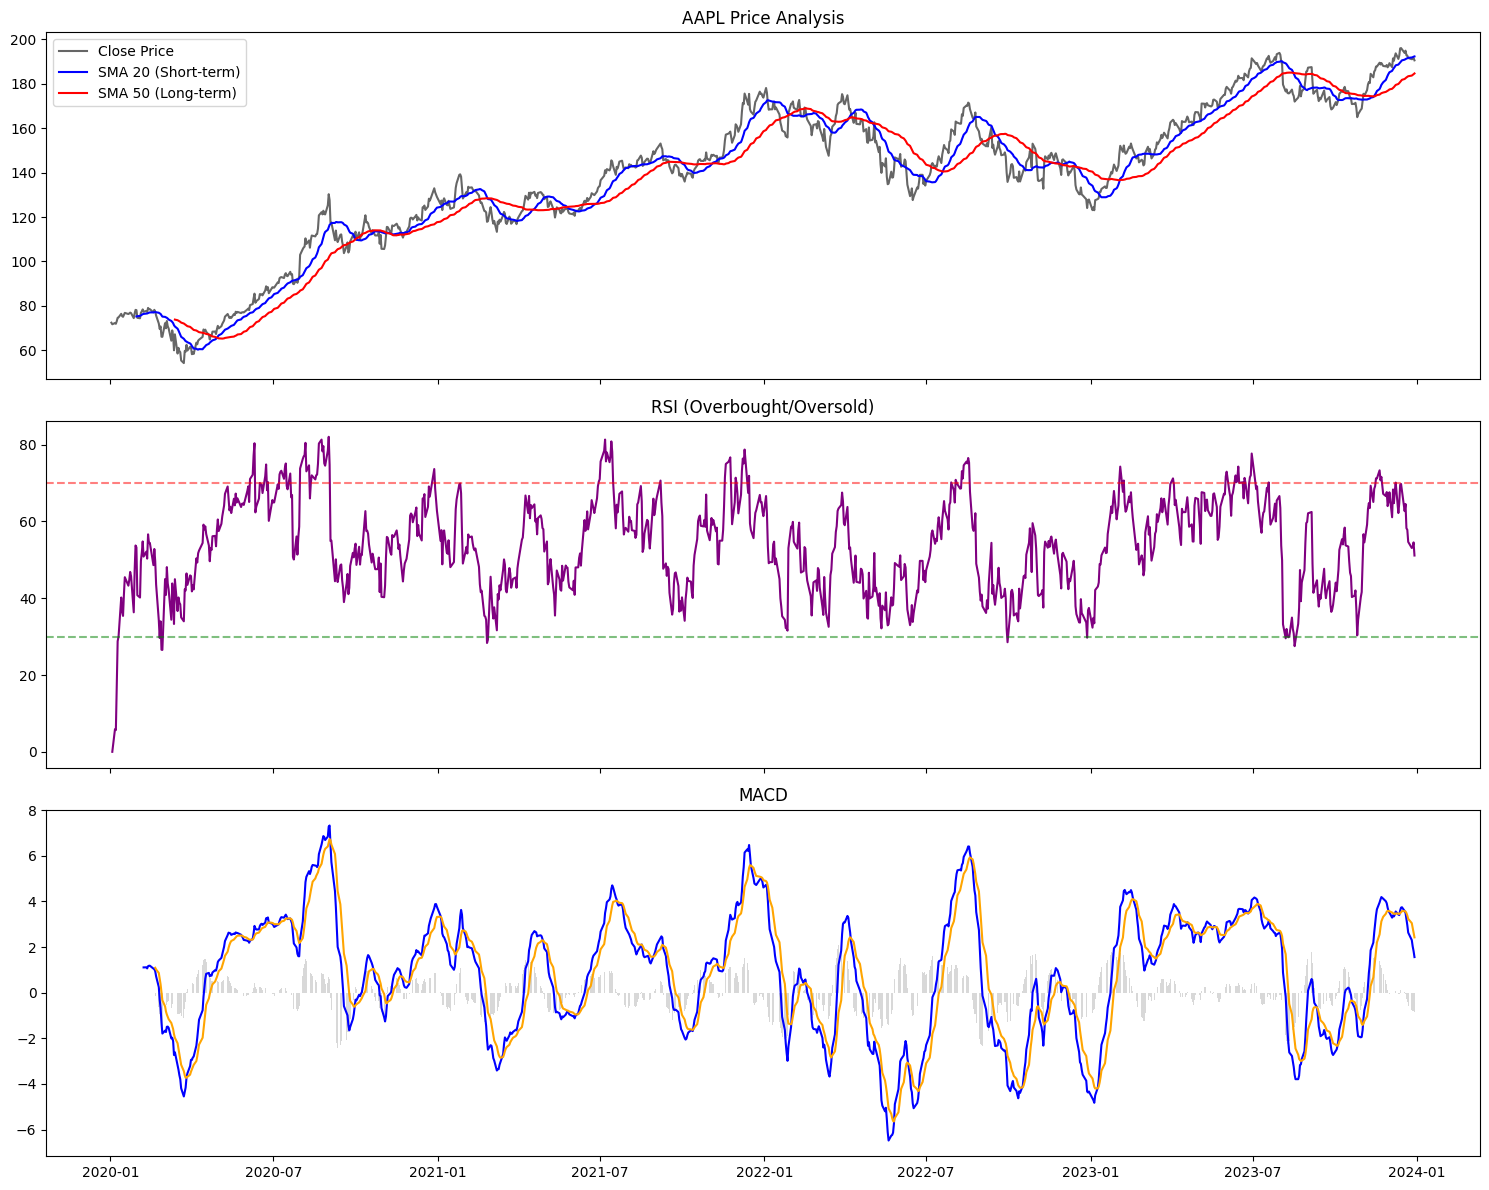

In [4]:
# Create a figure with 3 subplots (Price, RSI, MACD)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Panel 1: Price and Moving Averages
ax1.plot(df.index, df['Close'], label='Close Price', color='black', alpha=0.6)
ax1.plot(df.index, df['SMA_20'], label='SMA 20 (Short-term)', color='blue')
ax1.plot(df.index, df['SMA_50'], label='SMA 50 (Long-term)', color='red')
ax1.set_title(f'{ticker} Price Analysis')
ax1.legend()

# Panel 2: RSI (Momentum)
ax2.plot(df.index, df['RSI_14'], label='RSI', color='purple')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5) # Overbought line
ax2.axhline(30, color='green', linestyle='--', alpha=0.5) # Oversold line
ax2.set_title('RSI (Overbought/Oversold)')

# Panel 3: MACD (Trend Momentum)
ax3.plot(df.index, df['MACD_12_26_9'], label='MACD Line', color='blue')
ax3.plot(df.index, df['MACDs_12_26_9'], label='Signal Line', color='orange')
ax3.bar(df.index, df['MACDh_12_26_9'], label='Histogram', color='gray', alpha=0.3)
ax3.set_title('MACD')

plt.tight_layout()
plt.show()

In [6]:
# --- Manual Validation of Technical Indicators (Simulating TA-Lib Logic) ---

# TA-Lib's SMA is simply a rolling mean of the closing price.
# Here we calculate it manually using pure Pandas to validate our library output.

# 1. Manual Calculation (The math behind TA-Lib)
df['SMA_Manual_20'] = df['Close'].rolling(window=20).mean()

# 2. Validation Check: Compare pandas_ta ['SMA_20'] with our Manual ['SMA_Manual_20']
# We check the difference between the two methods
difference = (df['SMA_20'] - df['SMA_Manual_20']).abs().sum()

print(f"Validation Result:")
print(f"Total Absolute Difference: {difference:.6f}")

if difference < 0.0001:
    print("✅ VALIDATION SUCCESS: The pandas_ta SMA matches the manual math logic used by TA-Lib.")
else:
    print("❌ VALIDATION NOTICE: Minor numerical differences detected.")

display(df[['Close', 'SMA_20', 'SMA_Manual_20']].tail())

Validation Result:
Total Absolute Difference: 0.000000
✅ VALIDATION SUCCESS: The pandas_ta SMA matches the manual math logic used by TA-Lib.


,Close,SMA_20,SMA_Manual_20
Date,,,
2023-12-22,191.609497,191.677264,191.677264
2023-12-26,191.065094,191.838588,191.838588
2023-12-27,191.164093,191.974674,191.974674
2023-12-28,191.589661,192.183009,192.183009
2023-12-29,190.550476,192.310683,192.310683


### 📈 Technical Indicator Narrative & Trading Strategy
To support professional-grade trading decisions, the following parameters were selected:

1. **SMA 20 (Short-term Horizon):**
   - **Choice:** 20 days represents one full trading month.
   - **Logic:** Used to identify short-term trends. When the price is consistently above the SMA 20, it signals a "Buy" or "Hold" for swing traders.

2. **SMA 50 (Medium-term Horizon):**
   - **Choice:** 50 days is the industry standard for institutional support levels.
   - **Strategy:** We look for the **'Golden Cross'** (SMA 20 crossing above SMA 50) as a strong signal for a long-term trend reversal.

3. **RSI 14 (Momentum & Risk):**
   - **Choice:** A 14-period window balances sensitivity and noise.
   - **Trading Decision:** If RSI > 70 (Overbought), we tighten stop-losses. If RSI < 30 (Oversold) occurs simultaneously with positive news sentiment (Task 3), it creates a high-probability entry point.